# Regressao Linear com PyTorch - House Sales Prediction

## Objetivos

Este estudo segue a mesma ideia do exemplo do professor, mas usando o dataset de casas do Kaggle: https://www.kaggle.com/datasets/harlfoxem/housesalesprediction.

Voce vai praticar:
- preparacao de dados para regressao linear,
- normalizacao com StandardScaler,
- divisao entre treino e validacao,
- treinamento de um modelo linear com PyTorch (nn.Linear),
- avaliacao com perdas e metricas no valor real do preco.

## Importacao dos pacotes

In [1]:
%matplotlib inline
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn, optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
torch.manual_seed(1234)

## Leitura dos dados (House Sales)

In [2]:
print("Diretorio atual:", Path.cwd())

Diretorio atual: c:\Users\vinic\OneDrive\Desktop\Analista de Dados\Eng e Analise de Dados - CESAR\7- Redes Neurais\Atividade 2.6 V\Atividade 2.6


In [3]:
def load_house_sales_data():
    # 1) Tenta arquivo local primeiro (forma mais comum em aula)
    local_candidates = [
        Path("kc_house_data.csv"),
        Path("house_data.csv"),
        Path("data/kc_house_data.csv")
    ]
    for candidate in local_candidates:
        if candidate.exists():
            df_local = pd.read_csv(candidate)
            return df_local, str(candidate)

    # 2) Tenta baixar direto do KaggleHub
    try:
        import kagglehub
        dataset_dir = Path(kagglehub.dataset_download("harlfoxem/housesalesprediction"))
        csv_files = list(dataset_dir.glob("*.csv"))
        if csv_files:
            df_kaggle = pd.read_csv(csv_files[0])
            return df_kaggle, str(csv_files[0])
    except Exception as err:
        print("KaggleHub nao disponivel ou sem acesso:", err)

    # 3) Fallback: copia publica do mesmo dataset
    fallback_url = "https://raw.githubusercontent.com/loiccohen/HousePrices/master/data/kc_house_data.csv"
    df_fallback = pd.read_csv(fallback_url)
    return df_fallback, fallback_url

df, data_source = load_house_sales_data()
print("Fonte dos dados:", data_source)

Fonte dos dados: C:\Users\vinic\.cache\kagglehub\datasets\harlfoxem\housesalesprediction\versions\1\kc_house_data.csv


In [4]:
print("Dimensoes do dataset:", df.shape)
df.head()

Dimensoes do dataset: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [5]:
# Conversao da data para variaveis numericas
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["sale_year"] = df["date"].dt.year.fillna(0).astype(int)
df["sale_month"] = df["date"].dt.month.fillna(0).astype(int)

# Colunas de entrada (features)
feature_cols = [
    "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors",
    "waterfront", "view", "condition", "grade",
    "sqft_above", "sqft_basement", "yr_built", "yr_renovated",
    "lat", "long", "sqft_living15", "sqft_lot15",
    "sale_year", "sale_month"
]

target_col = "price"

X = df[feature_cols].copy()
y = df[[target_col]].copy()

# Tratamento simples para evitar NaN
X = X.fillna(X.median(numeric_only=True))
y = y.fillna(y.median(numeric_only=True))

In [6]:
print("Features selecionadas:", len(feature_cols))
print("Exemplo de X:")
display(X.head())
print("Exemplo de y (price):")
display(y.head())

Features selecionadas: 19
Exemplo de X:


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,47.5112,-122.257,1340,5650,2014,10
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,47.7210,-122.319,1690,7639,2014,12
2,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,47.7379,-122.233,2720,8062,2015,2
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,47.5208,-122.393,1360,5000,2014,12
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,47.6168,-122.045,1800,7503,2015,2


Exemplo de y (price):


,price
0,221900.0
1,538000.0
2,180000.0
3,604000.0
4,510000.0


### Pre-processamento e normalizacao dos dados

In [7]:
# Normalizacao das entradas
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X.values)

# Normalizacao do alvo (preco)
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.values)

In [8]:
# Divisao treino/validacao (70/30)
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled,
    y_scaled,
    test_size=0.3,
    random_state=42
)

# Conversao para tensores float32
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_val_tensor shape:", X_val_tensor.shape)
print("y_val_tensor shape:", y_val_tensor.shape)

X_train_tensor shape: torch.Size([15129, 19])
y_train_tensor shape: torch.Size([15129, 1])
X_val_tensor shape: torch.Size([6484, 19])
y_val_tensor shape: torch.Size([6484, 1])


## Criação do modelo da rede

In [9]:
input_dim = X_train_tensor.shape[1]
model = torch.nn.Linear(input_dim, 1)
print("Modelo criado com", input_dim, "features de entrada.")

Modelo criado com 19 features de entrada.


### Verificando a inicialização dos parâmetros

In [10]:
print("Peso inicial (primeiras 5 colunas):")
print(model.weight.data[:, :5])
print("Bias inicial:")
print(model.bias.data)

Peso inicial (primeiras 5 colunas):
tensor([[-0.2161, -0.0450, -0.1102, -0.0612, -0.2027]])
Bias inicial:
tensor([0.1061])


### Testando o predict da rede

In [11]:
model(torch.ones(5, input_dim))

tensor([[-0.3875],
        [-0.3875],
        [-0.3875],
        [-0.3875],
        [-0.3875]], grad_fn=<AddmmBackward0>)

In [12]:
model(X_train_tensor[:3])

tensor([[ 0.0051],
        [ 0.3321],
        [-0.5109]], grad_fn=<AddmmBackward0>)

## Treinamento

### Definindo função de perda e otimizador

In [13]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.05)
num_epochs = 300

### Laço de treinamento

In [14]:
def train_epoch(model, optimizer, criterion, X_train, y_train):
    model.train() # Set model to training mode
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backward and optimize
    loss.backward()
    optimizer.step()

    return loss.item() # Return scalar loss value

In [15]:
def validate_epoch(model, criterion, X_val, y_val):
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculations
        outputs = model(X_val)
        loss = criterion(outputs, y_val)
    return loss.item() # Return scalar loss value

In [16]:
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training step
    train_loss = train_epoch(model, optimizer, criterion, X_train_tensor, y_train_tensor)
    train_losses.append(train_loss)

    # Validation step
    val_loss = validate_epoch(model, criterion, X_val_tensor, y_val_tensor)
    val_losses.append(val_loss)

    # verbose
    if (epoch + 1) % 2 == 0:
        print(f'Epoch[{epoch+1}/{num_epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

Epoch[2/300], Train Loss: 0.739184, Val Loss: 0.562607
Epoch[4/300], Train Loss: 0.435502, Val Loss: 0.441388
Epoch[6/300], Train Loss: 0.382865, Val Loss: 0.403974
Epoch[8/300], Train Loss: 0.358769, Val Loss: 0.382906
Epoch[10/300], Train Loss: 0.343634, Val Loss: 0.368983
Epoch[12/300], Train Loss: 0.333206, Val Loss: 0.359182
Epoch[14/300], Train Loss: 0.325645, Val Loss: 0.352008
Epoch[16/300], Train Loss: 0.319963, Val Loss: 0.346613
Epoch[18/300], Train Loss: 0.315578, Val Loss: 0.342472
Epoch[20/300], Train Loss: 0.312126, Val Loss: 0.339243
Epoch[22/300], Train Loss: 0.309361, Val Loss: 0.336693
Epoch[24/300], Train Loss: 0.307116, Val Loss: 0.334657
Epoch[26/300], Train Loss: 0.305271, Val Loss: 0.333016
Epoch[28/300], Train Loss: 0.303738, Val Loss: 0.331683
Epoch[30/300], Train Loss: 0.302452, Val Loss: 0.330592
Epoch[32/300], Train Loss: 0.301364, Val Loss: 0.329694
Epoch[34/300], Train Loss: 0.300437, Val Loss: 0.328950
Epoch[36/300], Train Loss: 0.299641, Val Loss: 0.328

## Avaliação

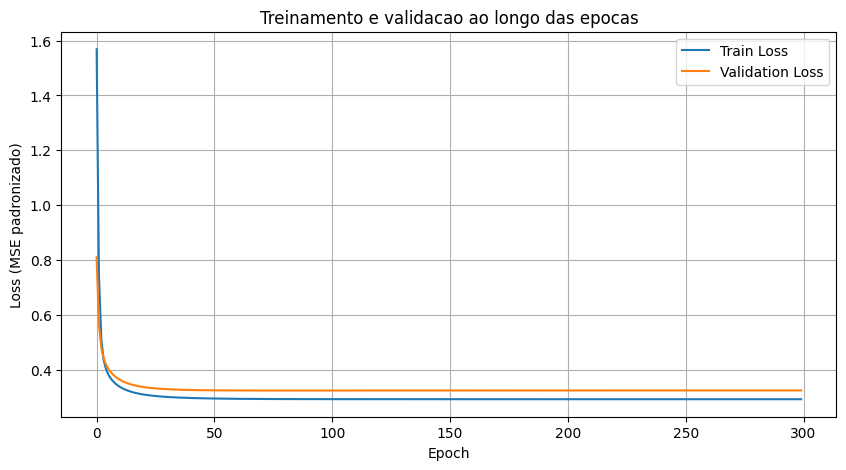

MAE:  127,426.09
RMSE: 209,500.79
R2:   0.6960


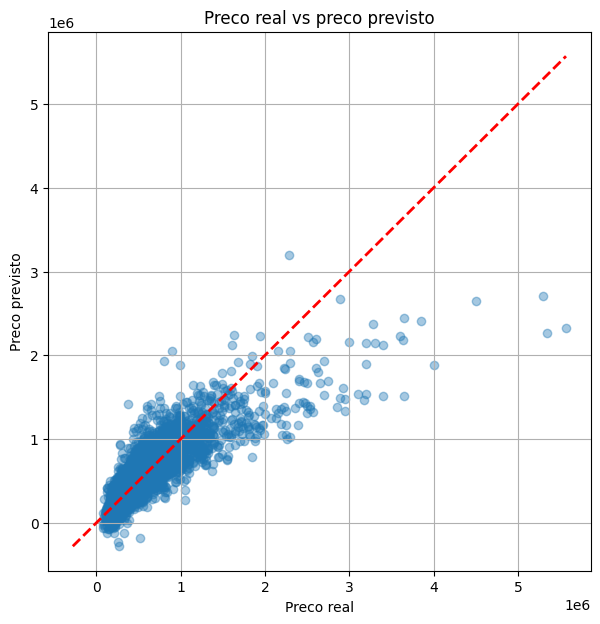

In [18]:
# Curvas de perda
plt.figure(figsize=(10, 5))
plt.plot(range(num_epochs), train_losses, label='Train Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE padronizado)')
plt.title('Treinamento e validacao ao longo das epocas')
plt.legend()
plt.grid(True)
plt.show()

# Predicoes no conjunto de validacao
model.eval()
with torch.no_grad():
    y_val_pred_scaled = model(X_val_tensor).numpy()

# Volta para a escala real do preco
y_val_real = y_scaler.inverse_transform(y_val)
y_val_pred_real = y_scaler.inverse_transform(y_val_pred_scaled)

mae = mean_absolute_error(y_val_real, y_val_pred_real)
rmse = np.sqrt(mean_squared_error(y_val_real, y_val_pred_real))
r2 = r2_score(y_val_real, y_val_pred_real)

print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2:   {r2:.4f}")

# Grafico real vs previsto
plt.figure(figsize=(7, 7))
plt.scatter(y_val_real, y_val_pred_real, alpha=0.4)
min_v = min(y_val_real.min(), y_val_pred_real.min())
max_v = max(y_val_real.max(), y_val_pred_real.max())
plt.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2)
plt.xlabel('Preco real')
plt.ylabel('Preco previsto')
plt.title('Preco real vs preco previsto')
plt.grid(True)
plt.show()